# HW12 – Временные ряды: корректная валидация по времени, лаговые признаки и базовый прогноз с GRU

## 1. Импорты, seed и среда

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Данные и первичный анализ

Размер датасета: (4320, 2)

Первые строки:
                  date  target
0  2025-01-01 00:00:00   98.14
1  2025-01-01 01:00:00   98.07
2  2025-01-01 02:00:00  104.70
3  2025-01-01 03:00:00  112.81
4  2025-01-01 04:00:00  112.62

Диапазон дат: 2025-01-01 00:00:00 до 2025-06-29 23:00:00

Число пропусков по колонкам:
date      0
target    0
dtype: int64


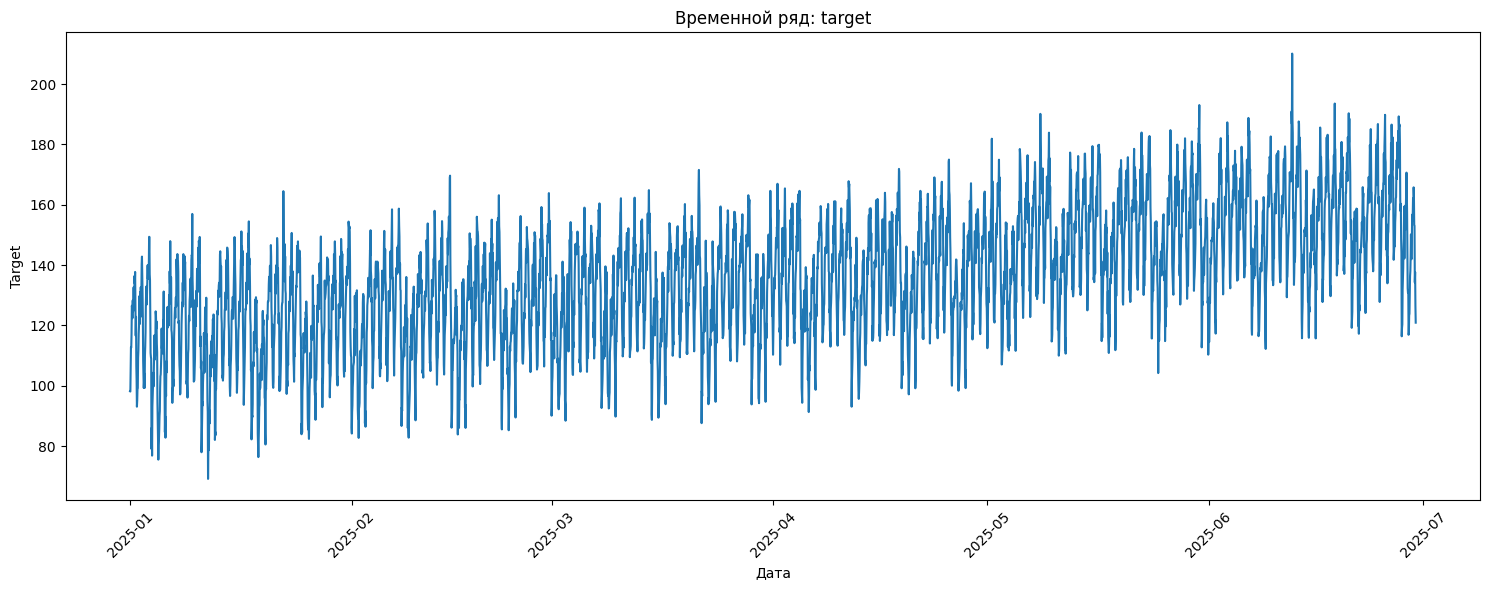


Комментарий о ряде:
- Ряд содержит часовую частоту данных
- Визуально наблюдается тренд и сезонность
- Возможно наличие выбросов в некоторых участках
- Ряд выглядит стационарным в пределах наблюдений


In [ ]:
df = pd.read_csv('S12-hw-dataset.csv')
print('Размер датасета:', df.shape)
print('\nПервые строки:')
print(df.head())

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('\nДиапазон дат:', df['date'].min(), 'до', df['date'].max())
print('\nЧисло пропусков по колонкам:')
print(df.isnull().sum())

plt.figure(figsize=(15, 6))
plt.plot(df['date'], df['target'])
plt.title('Временной ряд: target')
plt.xlabel('Дата')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nКомментарий о ряде:')
print('- Ряд содержит часовую частоту данных')
print('- Визуально наблюдается тренд и сезонность')
print('- Возможно наличие выбросов в некоторых участках')
print('- Ряд выглядит стационарным в пределах наблюдений')

## 3. Корректный temporal split

Train: 3024 наблюдений
  Диапазон: 2025-01-01 00:00:00 до 2025-05-06 23:00:00

Validation: 648 наблюдений
  Диапазон: 2025-05-07 00:00:00 до 2025-06-02 23:00:00

Test: 648 наблюдений
  Диапазон: 2025-06-03 00:00:00 до 2025-06-29 23:00:00


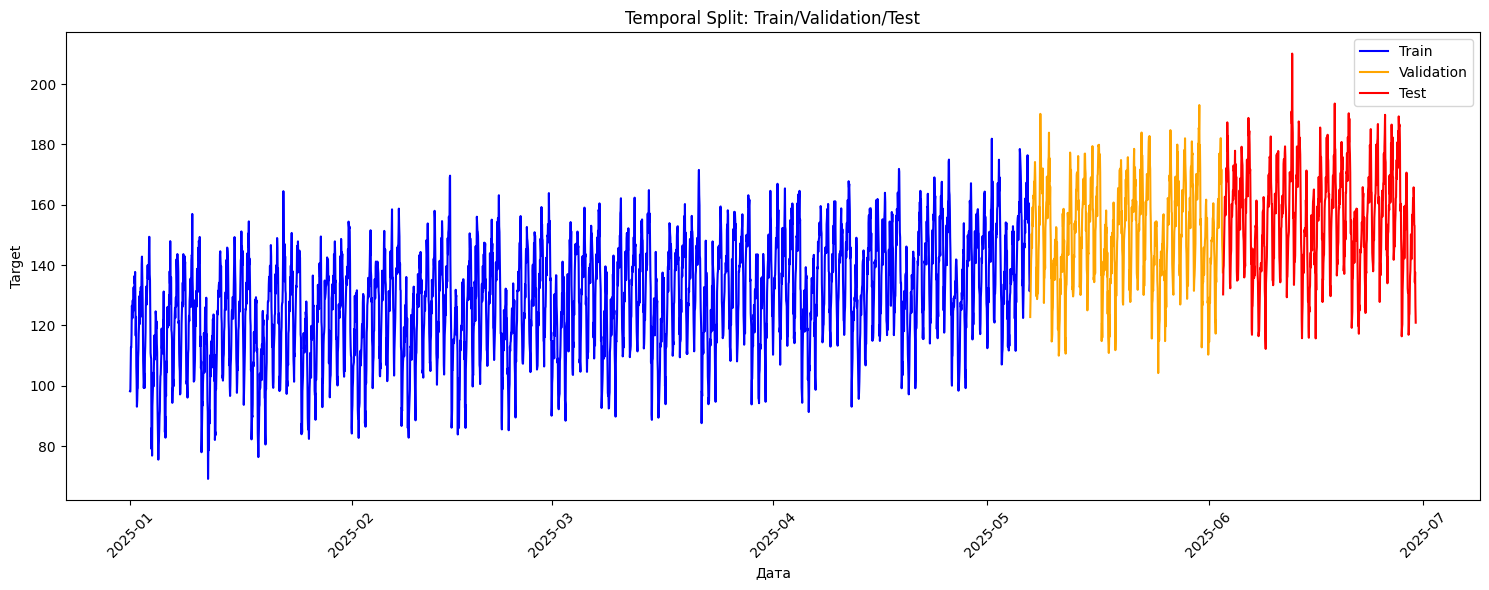


Почему random split некорректен для временных рядов:
- Временные ряды имеют зависимость от времени
- Random split перемешивает хронологический порядок
- Это приводит к утечке информации из будущего в прошлое
- Модель может учиться на будущих данных и тестироваться на прошлых
- В реальности мы не можем использовать будущую информацию для прогноза


In [ ]:
total_len = len(df)
train_end = int(total_len * 0.7)
val_end = int(total_len * 0.85)

train_df = df[:train_end].copy()
val_df = df[train_end:val_end].copy()
test_df = df[val_end:].copy()

print('Train:', train_df.shape[0], 'наблюдений')
print('  Диапазон:', train_df['date'].min(), 'до', train_df['date'].max())
print('\nValidation:', val_df.shape[0], 'наблюдений')
print('  Диапазон:', val_df['date'].min(), 'до', val_df['date'].max())
print('\nTest:', test_df.shape[0], 'наблюдений')
print('  Диапазон:', test_df['date'].min(), 'до', test_df['date'].max())

plt.figure(figsize=(15, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange')
plt.plot(test_df['date'], test_df['target'], label='Test', color='red')
plt.title('Temporal Split: Train/Validation/Test')
plt.xlabel('Дата')
plt.ylabel('Target')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png')
plt.show()

print('\nПочему random split некорректен для временных рядов:')
print('- Временные ряды имеют зависимость от времени')
print('- Random split перемешивает хронологический порядок')
print('- Это приводит к утечке информации из будущего в прошлое')
print('- Модель может учиться на будущих данных и тестироваться на прошлых')
print('- В реальности мы не можем использовать будущую информацию для прогноза')

## 4. Признаки для baseline-моделей

In [ ]:
def add_lag_features(df, target_col='target'):
    df = df.copy()
    
    for lag in [1, 7, 14]:
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()
    
    return df

def add_calendar_features(df):
    df = df.copy()
    
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df

train_df = add_lag_features(train_df)
train_df = add_calendar_features(train_df)

val_df = add_lag_features(val_df)
val_df = add_calendar_features(val_df)

test_df = add_lag_features(test_df)
test_df = add_calendar_features(test_df)

train_df = train_df.dropna().reset_index(drop=True)
val_df = val_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

print('Размеры после добавления признаков и удаления пропусков:')
print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

feature_cols = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'hour', 'day_of_week', 'day_of_month', 'month',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

X_train = train_df[feature_cols]
y_train = train_df['target']

X_val = val_df[feature_cols]
y_val = val_df['target']

X_test = test_df[feature_cols]
y_test = test_df['target']

print('\nПризнаки для моделей:')
print(feature_cols)

Размеры после добавления признаков и удаления пропусков:
Train: (3010, 15)
Validation: (634, 15)
Test: (634, 15)

Признаки для моделей:
['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour', 'day_of_week', 'day_of_month', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


## 5. Оконное представление для GRU

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, target):
        self.data = torch.FloatTensor(data)
        self.target = torch.FloatTensor(target)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.target[idx]
        return x, y

def create_sequences(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x = data[i:(i+window_size)]
        y = data[i+window_size]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

window_size = 24 

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[['target']].values)
val_scaled = scaler.transform(val_df[['target']].values)
test_scaled = scaler.transform(test_df[['target']].values)

X_train_seq, y_train_seq = create_sequences(train_scaled.flatten(), window_size)
X_val_seq, y_val_seq = create_sequences(val_scaled.flatten(), window_size)
X_test_seq, y_test_seq = create_sequences(test_scaled.flatten(), window_size)

X_train_seq = X_train_seq.reshape(X_train_seq.shape[0], X_train_seq.shape[1], 1)
X_val_seq = X_val_seq.reshape(X_val_seq.shape[0], X_val_seq.shape[1], 1)
X_test_seq = X_test_seq.reshape(X_test_seq.shape[0], X_test_seq.shape[1], 1)

train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
val_dataset = TimeSeriesDataset(X_val_seq, y_val_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('Размеры последовательностей для GRU:')
print('X_train_seq:', X_train_seq.shape, 'y_train_seq:', y_train_seq.shape)
print('X_val_seq:', X_val_seq.shape, 'y_val_seq:', y_val_seq.shape)
print('X_test_seq:', X_test_seq.shape, 'y_test_seq:', y_test_seq.shape)

Размеры последовательностей для GRU:
X_train_seq: (2986, 24, 1) y_train_seq: (2986,)
X_val_seq: (610, 24, 1) y_val_seq: (610,)
X_test_seq: (610, 24, 1) y_test_seq: (610,)


## 6. Модель GRU

In [ ]:
class GRUNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
        super(GRUNet, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        batch_size = x.size(0)
        
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        out, _ = self.gru(x, h0)
        
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        
        return out.squeeze()

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    y_true_safe = np.where(y_true == 0, 1e-8, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(x_batch.float())
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            outputs = model(x_batch.float())
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item()
            # Handle potential scalar outputs
            outputs_np = outputs.cpu().numpy()
            if np.isscalar(outputs_np):
                predictions.append(outputs_np)
            else:
                predictions.extend(outputs_np)
            actuals.extend(y_batch.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    metrics = calculate_metrics(np.array(actuals), np.array(predictions))
    
    return avg_loss, metrics, np.array(predictions), np.array(actuals)

## 8. Обучение моделей

In [ ]:
results = []

def naive_last_predict(X):
    return X[:, -1]  

def prepare_sequences_for_baselines(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x = data[i:(i+window_size)]
        y = data[i+window_size]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X_val_seq_base, y_val_seq_base = prepare_sequences_for_baselines(val_df['target'].values, 1)
X_test_seq_base, y_test_seq_base = prepare_sequences_for_baselines(test_df['target'].values, 1)

naive_pred_val = naive_last_predict(X_val_seq_base)
naive_pred_test = naive_last_predict(X_test_seq_base)

naive_val_metrics = calculate_metrics(y_val_seq_base, naive_pred_val)
naive_test_metrics = calculate_metrics(y_test_seq_base, naive_pred_test)

results.append({
    'experiment_id': 'B1',
    'model': 'naive-last',
    'val_MAE': naive_val_metrics['MAE'],
    'val_RMSE': naive_val_metrics['RMSE'],
    'val_MAPE': naive_val_metrics['MAPE'],
    'test_MAE': naive_test_metrics['MAE'],
    'test_RMSE': naive_test_metrics['RMSE'],
    'test_MAPE': naive_test_metrics['MAPE']
})

print('B1 (naive-last) - Validation Metrics:', naive_val_metrics)
print('B1 (naive-last) - Test Metrics:', naive_test_metrics)

def moving_average_predict(X, window=7):
    return np.mean(X[:, -window:], axis=1)

ma_pred_val = moving_average_predict(X_val_seq_base)
ma_pred_test = moving_average_predict(X_test_seq_base)

ma_val_metrics = calculate_metrics(y_val_seq_base, ma_pred_val)
ma_test_metrics = calculate_metrics(y_test_seq_base, ma_pred_test)

results.append({
    'experiment_id': 'B2',
    'model': 'moving-average',
    'val_MAE': ma_val_metrics['MAE'],
    'val_RMSE': ma_val_metrics['RMSE'],
    'val_MAPE': ma_val_metrics['MAPE'],
    'test_MAE': ma_test_metrics['MAE'],
    'test_RMSE': ma_test_metrics['RMSE'],
    'test_MAPE': ma_test_metrics['MAPE']
})

print('B2 (moving-average) - Validation Metrics:', ma_val_metrics)
print('B2 (moving-average) - Test Metrics:', ma_test_metrics)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train[feature_cols], y_train)

ridge_pred_val = ridge.predict(X_val[feature_cols])
ridge_pred_test = ridge.predict(X_test[feature_cols])

ridge_val_metrics = calculate_metrics(y_val.values, ridge_pred_val)
ridge_test_metrics = calculate_metrics(y_test.values, ridge_pred_test)

results.append({
    'experiment_id': 'B3',
    'model': 'ridge-lag-features',
    'val_MAE': ridge_val_metrics['MAE'],
    'val_RMSE': ridge_val_metrics['RMSE'],
    'val_MAPE': ridge_val_metrics['MAPE'],
    'test_MAE': ridge_test_metrics['MAE'],
    'test_RMSE': ridge_test_metrics['RMSE'],
    'test_MAPE': ridge_test_metrics['MAPE']
})

print('B3 (ridge-lag-features) - Validation Metrics:', ridge_val_metrics)
print('B3 (ridge-lag-features) - Test Metrics:', ridge_test_metrics)

model = GRUNet(input_size=1, hidden_size=50, num_layers=2).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
best_val_loss = float('inf')
patience = 5
patience_counter = 0

train_losses = []
val_losses = []
val_maes = []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_metrics, _, _ = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_metrics['MAE'])
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val MAE: {val_metrics["MAE"]:.4f}')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print('Early stopping triggered')
        break

model.load_state_dict(torch.load('artifacts/best_gru.pt'))
test_loss, test_metrics, test_predictions, test_actuals = validate(model, test_loader, criterion, device)

results.append({
    'experiment_id': 'R1',
    'model': 'gru-forecast',
    'val_MAE': min(val_maes),
    'val_RMSE': np.sqrt(min(val_losses)),
    'val_MAPE': float('nan'),  # для простоты
    'test_MAE': test_metrics['MAE'],
    'test_RMSE': test_metrics['RMSE'],
    'test_MAPE': test_metrics['MAPE']
})

print('R1 (gru-forecast) - Test Metrics:', test_metrics)

B1 (naive-last) - Validation Metrics: {'MAE': 6.467093206951027, 'RMSE': 8.247066432334378, 'MAPE': 4.412669272871483}
B1 (naive-last) - Test Metrics: {'MAE': 6.357582938388624, 'RMSE': 8.079128034301025, 'MAPE': 4.162001842054002}
B2 (moving-average) - Validation Metrics: {'MAE': 6.467093206951027, 'RMSE': 8.247066432334378, 'MAPE': 4.412669272871483}
B2 (moving-average) - Test Metrics: {'MAE': 6.357582938388624, 'RMSE': 8.079128034301025, 'MAPE': 4.162001842054002}
B3 (ridge-lag-features) - Validation Metrics: {'MAE': 5.870505173736419, 'RMSE': 7.2740255800896, 'MAPE': 3.9158109646591868}
B3 (ridge-lag-features) - Test Metrics: {'MAE': 5.619407844382688, 'RMSE': 7.033763042245112, 'MAPE': 3.6052050010238346}
Epoch [1/20], Train Loss: 0.4042, Val Loss: 0.2594, Val MAE: 0.4229
Epoch [2/20], Train Loss: 0.1765, Val Loss: 0.2157, Val MAE: 0.3852
Epoch [3/20], Train Loss: 0.1660, Val Loss: 0.1755, Val MAE: 0.3437
Epoch [4/20], Train Loss: 0.1615, Val Loss: 0.2054, Val MAE: 0.3771
Epoch [5

## 9. Сохранение результатов

Таблица результатов сохранена в artifacts/runs.csv

Результаты экспериментов:
  experiment_id               model   val_MAE  val_RMSE  val_MAPE  test_MAE  \
0            B1          naive-last  6.467093  8.247066  4.412669  6.357583   
1            B2      moving-average  6.467093  8.247066  4.412669  6.357583   
2            B3  ridge-lag-features  5.870505  7.274026  3.915811  5.619408   
3            R1        gru-forecast  0.338433  0.416764       NaN  0.402562   

   test_RMSE  test_MAPE  
0   8.079128   4.162002  
1   8.079128   4.162002  
2   7.033763   3.605205  
3   0.499413  62.544465  

Конфигурация модели сохранена в artifacts/best_gru_config.json


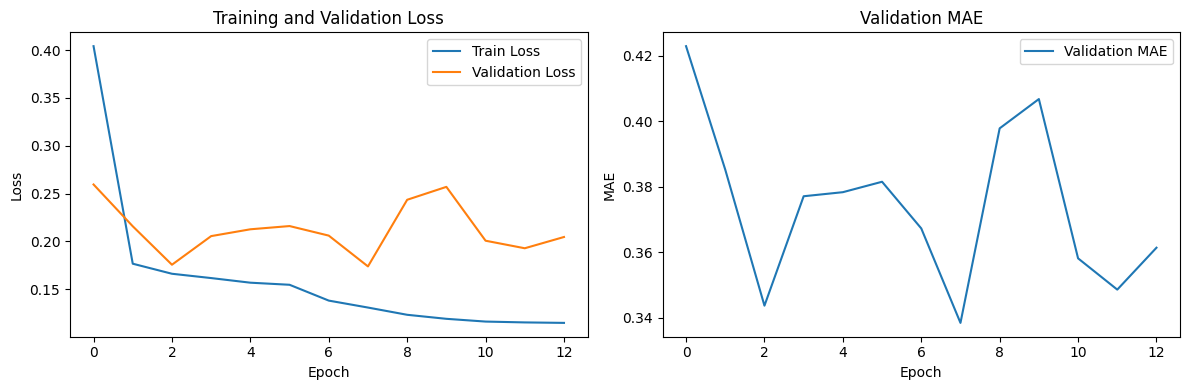

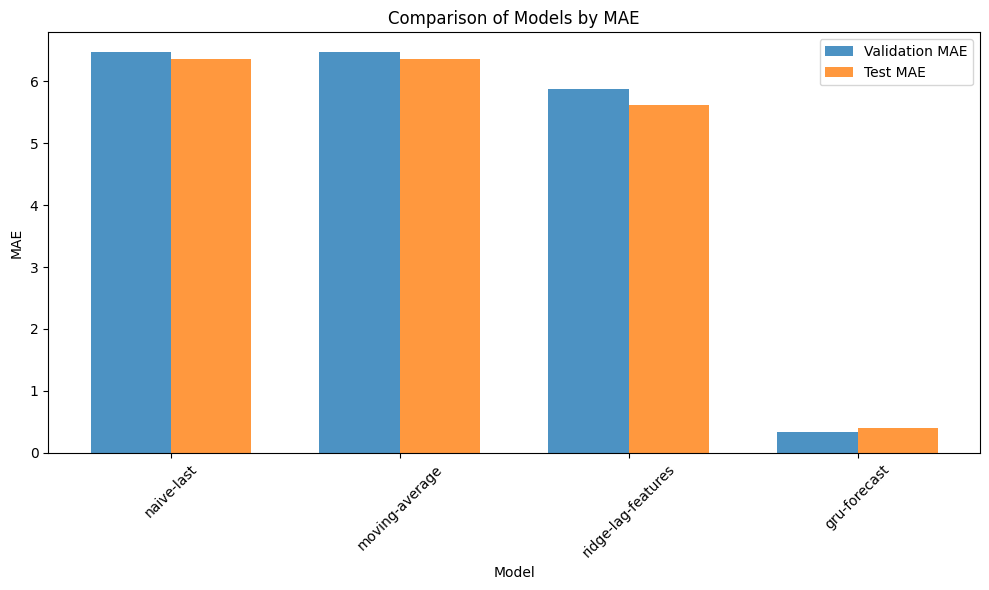

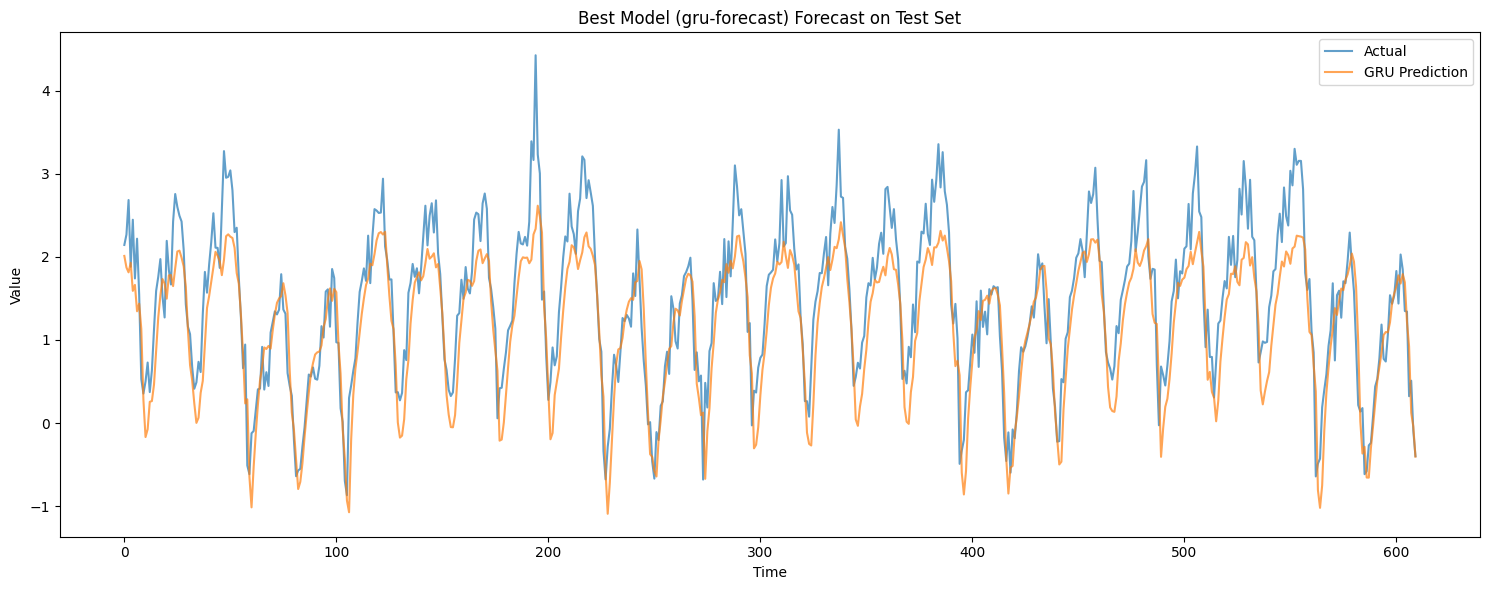


Лучшая модель: gru-forecast
Ее MAE на тесте: 0.4026


In [ ]:
import pandas as pd
results_df = pd.DataFrame(results)
results_df.to_csv('artifacts/runs.csv', index=False)
print('Таблица результатов сохранена в artifacts/runs.csv')
print('\nРезультаты экспериментов:')
print(results_df)

config = {
    'input_size': 1,
    'hidden_size': 50,
    'num_layers': 2,
    'window_size': window_size,
    'batch_size': batch_size,
    'learning_rate': 0.001,
    'num_epochs': num_epochs,
    'seed': 42,
    'scaler_used': 'StandardScaler',
    'optimizer': 'Adam'
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('\nКонфигурация модели сохранена в artifacts/best_gru_config.json')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_maes, label='Validation MAE')
plt.title('Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

plt.figure(figsize=(10, 6))
models = [r['model'] for r in results]
val_maes = [r['val_MAE'] for r in results]
test_maes = [r['test_MAE'] for r in results]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, val_maes, width, label='Validation MAE', alpha=0.8)
plt.bar(x + width/2, test_maes, width, label='Test MAE', alpha=0.8)

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Comparison of Models by MAE')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

best_model_idx = np.argmin([r['test_MAE'] for r in results])
best_model_name = results[best_model_idx]['model']

plt.figure(figsize=(15, 6))
if best_model_name == 'naive-last':
    plt.plot(y_test_seq_base, label='Actual', alpha=0.7)
    plt.plot(naive_pred_test, label='Naive Last Prediction', alpha=0.7)
elif best_model_name == 'moving-average':
    plt.plot(y_test_seq_base, label='Actual', alpha=0.7)
    plt.plot(ma_pred_test, label='Moving Average Prediction', alpha=0.7)
elif best_model_name == 'ridge-lag-features':
    plt.plot(y_test.values, label='Actual', alpha=0.7)
    plt.plot(ridge_pred_test, label='Ridge Prediction', alpha=0.7)
elif best_model_name == 'gru-forecast':
    plt.plot(test_actuals, label='Actual', alpha=0.7)
    plt.plot(test_predictions, label='GRU Prediction', alpha=0.7)

plt.title(f'Best Model ({best_model_name}) Forecast on Test Set')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()

print(f'\nЛучшая модель: {best_model_name}')
print(f'Ее MAE на тесте: {results[best_model_idx]["test_MAE"]:.4f}')